# 📦 Phase 1: Data Cleaning & Gold Layer Transformation
**Project:** Brazilian E-commerce (Olist) — Sales Performance & Growth Analysis
**Status:** `Data Refinery (Silver to Gold)`
**Engineer:** MDA Specialist

---

## 🎯 Project Objective
Mentransformasi dataset mentah `master_join` (119k baris) menjadi **Gold Standard Data** yang bersih, konsisten, dan bebas anomali. Tahap ini adalah prasyarat krusial sebelum melakukan **EDA (Phase 2)** guna menjamin akurasi *Business Insights*.

## 🛠️ Data Quality Workflow
Alur pembersihan data mengikuti standar industri e-commerce global:

| Langkah | Aktivitas Utama | Tujuan Bisnis (Why) |
| :--- | :--- | :--- |
| **1. Visual Audit** | Matriks Kekosongan (`missingno`) | Mengidentifikasi pola data yang hilang secara sistemik. |
| **2. Logical Filter** | Filter `order_status == 'delivered'` | Memastikan hanya pendapatan terealisasi yang dianalisis. |
| **3. Null Handling** | Imputasi Smart & Labeling | Menangani 44 kolom tanpa menghilangkan volume transaksi. |
| **4. Time Integrity** | Kronologi & Konversi Datetime | Menjamin validitas data untuk analisis tren pertumbuhan. |
| **5. Standardizing** | Text Formatting (Title/Upper Case) | Menghindari duplikasi entitas akibat perbedaan penulisan. |
| **6. Financial QA** | Outlier Removal & Price Validation | Menghapus anomali harga (Rp 0) untuk akurasi AOV & GMV. |
| **7. Deduplication** | Order & Item Key Validation | Mencegah *double-counting* pada unit transaksi. |



## 📈 Expected Output
* **Dataset:** `olist_data_cleaned.csv`
* **Data Quality:** 100% Integrity (No nulls in critical metrics).
* **Ready For:** Monthly Revenue, MAU Growth, Churn Rate, & Segment Analysis.

---

In [1]:
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- 1. KONFIGURASI VISUAL & TAMPILAN ---
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_style('whitegrid')

# --- 2. PENANGANAN PATH SECARA DINAMIS ---
# Menggunakan os.path.join agar script berjalan baik di Windows/Mac/Linux
base_path = os.getcwd()
# Pastikan folder data/processed sudah ada sesuai struktur project kamu
data_path = os.path.join("..", "..", "data", "processed", "olist_master_gold.csv")
# --- 3. PROSES LOADING DENGAN VALIDASI KETAT ---
print(f"🔍 Mencari file di: {os.path.abspath(data_path)}")

if os.path.exists(data_path):
    try:
        # Load Data
        df = pd.read_csv(data_path, low_memory=False)
        
        # Sukses! Sekarang tampilkan informasi dataset
        print("-" * 30)
        print(f"✅ DATA BERHASIL DIMUAT")
        print(f"📊 Dataset Shape: {df.shape[0]:,} baris | {df.shape[1]} kolom")
        print("-" * 30)
        
        # --- 4. AUDIT VISUAL INTEGRITAS DATA ---
        # Menampilkan matrix missing values untuk melihat 'lubang' pada data mentah
        plt.figure(figsize=(12, 6))
        msno.matrix(df)
        plt.title("Initial Data Integrity Audit (Gold Layer)", fontsize=18)
        plt.show()
        
        # Tampilkan 5 data teratas
        display(df.head())
        
    except Exception as e:
        print(f"❌ Terjadi kesalahan teknis saat membaca file: {e}")
else:
    print(f"⚠️ ERROR: File tidak ditemukan!")
    print(f"Saran: Cek apakah file 'olist_master_gold.csv' sudah ada di folder data/processed.")
    # Inisialisasi df kosong agar cell berikutnya tidak error 'df not defined'
    df = pd.DataFrame()

🔍 Mencari file di: c:\Users\etc\OneDrive\Documents\Marketing Data Analyst Portofolio\Olist_Ecommerce_Analytics_Portfolio\data\processed\olist_master_gold.csv
⚠️ ERROR: File tidak ditemukan!
Saran: Cek apakah file 'olist_master_gold.csv' sudah ada di folder data/processed.


In [2]:
# Filter status sukses
df_clean = df[df['order_status'] == 'delivered'].copy()
print(f"Baris setelah filtering status 'delivered': {len(df_clean)}")

Baris setelah filtering status 'delivered': 115723


In [3]:
# A. Financial Columns (Price & Freight)
# Mengapa: Tanpa harga, transaksi tidak memiliki nilai moneter untuk analisis sales.
df_clean.dropna(subset=['price', 'freight_value'], inplace=True)

# B. Categorical Columns
# Mengapa: Menghindari kehilangan data volume penjualan hanya karena kategori tidak terinput.
categorical_cols = df_clean.select_dtypes(include=['object']).columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna('Uncategorized')

# C. Review Columns
# Mengapa: Skor null dianggap netral (median), teks null diberi label agar tidak mengganggu analisis sentimen.
df_clean['review_score'] = df_clean['review_score'].fillna(df_clean['review_score'].median())
df_clean['review_comment_message'] = df_clean['review_comment_message'].fillna('No Comment Provided')

In [4]:
# Konversi ke Datetime
date_cols = [col for col in df_clean.columns if 'timestamp' in col or 'date' in col]
for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Imputasi Logis Tanggal Sampai
# Jika tanggal sampai kosong, gunakan estimasi (selama masuk akal secara bisnis)
df_clean['order_delivered_customer_date'] = df_clean['order_delivered_customer_date'].fillna(df_clean['order_estimated_delivery_date'])

# Hapus anomali waktu: Barang sampai tidak boleh lebih awal dari tanggal beli
df_clean = df_clean[df_clean['order_delivered_customer_date'] >= df_clean['order_purchase_timestamp']]

In [5]:
# ID Integrity
id_cols = ['order_id', 'customer_id', 'product_id', 'seller_id', 'customer_unique_id']
for col in id_cols:
    df_clean[col] = df_clean[col].astype(str)

# Location Formatting
df_clean['customer_city'] = df_clean['customer_city'].str.title()
df_clean['customer_state'] = df_clean['customer_state'].str.upper()

# Price Type
df_clean['price'] = df_clean['price'].astype(float)

In [6]:
# Price Validation
df_clean = df_clean[df_clean['price'] > 0]

# Deduplication pada level Item
df_clean.drop_duplicates(subset=['order_id', 'order_item_id'], keep='first', inplace=True)

# Feature Engineering: GMV (Gross Merchandise Value)
df_clean['total_order_value'] = df_clean['price'] + df_clean['freight_value']

In [7]:
print("="*50)
print("📊 GOLD DATA QUALITY REPORT")
print("="*50)
print(f"Total Baris Akhir    : {len(df_clean)}")
print(f"Total Kolom          : {len(df_clean.columns)}")
print(f"Missing Values       : {df_clean.isnull().sum().sum()}")
print(f"Periode Data         : {df_clean['order_purchase_timestamp'].min()} s/d {df_clean['order_purchase_timestamp'].max()}")
print("="*50)

# Export Data Cleaned
df_clean.to_csv('../../data/processed/olist_data_cleaned.csv', index=False)
print("🚀 Data Cleaned siap untuk EDA Tahap 2!")

📊 GOLD DATA QUALITY REPORT
Total Baris Akhir    : 110197
Total Kolom          : 44
Missing Values       : 7212
Periode Data         : 2016-09-15 12:16:38 s/d 2018-08-29 15:00:37
🚀 Data Cleaned siap untuk EDA Tahap 2!


In [9]:
# =================================================================
# FINAL REVISION: DATA INTEGRITY & LOGICAL CONSISTENCY (FIXED)
# =================================================================

print(f"Initial row count: {len(df_clean)}")

# --- A. Menangani Duplikasi Order yang Kompleks ---
# Menghapus hanya jika baris benar-benar identik pada kunci utama
df_clean = df_clean.drop_duplicates(subset=['order_id', 'order_item_id', 'product_id'], keep='first')

# --- B. Validasi Logika Waktu (Handling 'Uncategorized' Error) ---
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_customer_date']

for col in date_cols:
    # errors='coerce' akan mengubah teks "Uncategorized" menjadi NaT agar tidak error
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Hapus baris yang tanggal pembeliannya menjadi NaT (jika ada) karena fatal untuk analisis
df_clean = df_clean.dropna(subset=['order_purchase_timestamp'])

# Filter Anomali Logika Waktu
# 1. Approval harus setelah atau sama dengan pembelian
df_clean = df_clean[df_clean['order_approved_at'] >= df_clean['order_purchase_timestamp']]

# 2. Barang sampai harus setelah atau sama dengan pembelian
df_clean = df_clean[df_clean['order_delivered_customer_date'] >= df_clean['order_purchase_timestamp']]

# --- C. Sinkronisasi Kategori Produk ---
# Mengisi kolom bahasa Inggris dengan nilai kolom Portugal jika masih kosong
if 'product_category_name' in df_clean.columns:
    df_clean['product_category_name_english'] = df_clean['product_category_name_english'].replace("Uncategorized", np.nan)
    df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna(df_clean['product_category_name'])

# Pastikan nilai akhir tetap bersih
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna('others')
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].replace(np.nan, 'others')

# --- D. Final Quality Report ---
print("-" * 30)
print("✅ FINAL INTEGRITY CHECK COMPLETED")
print("-" * 30)
print(f"Final row count        : {len(df_clean):,}")
print(f"Date Conversion Status : SUCCESS (Non-date strings handled)")
print(f"Category Nulls (ENG)   : {df_clean['product_category_name_english'].isnull().sum()}")
print("-" * 30)

# Simpan hasil akhir ke folder processed
output_path = "../../data/processed/01_olist_master_join_cleaned.csv"
df_clean.to_csv(output_path, index=False)
print(f"🚀 File Gold Standard disimpan di: {output_path}")

Initial row count: 110197
------------------------------
✅ FINAL INTEGRITY CHECK COMPLETED
------------------------------
Final row count        : 110,182
Date Conversion Status : SUCCESS (Non-date strings handled)
Category Nulls (ENG)   : 0
------------------------------
🚀 File Gold Standard disimpan di: ../../data/processed/01_olist_master_join_cleaned.csv


C:\Users\etc\AppData\Local\Temp\ipykernel_2148\3645836733.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=['#e74c3c', '#2ecc71'], ax=ax3)
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\3645836733.py:33: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.90])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\3645836733.py:33: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.90])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\3645836733.py:33: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.90])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\3645836733.py:33: UserWarning: Glyph 128176 (\N{MONEY BAG}) missin

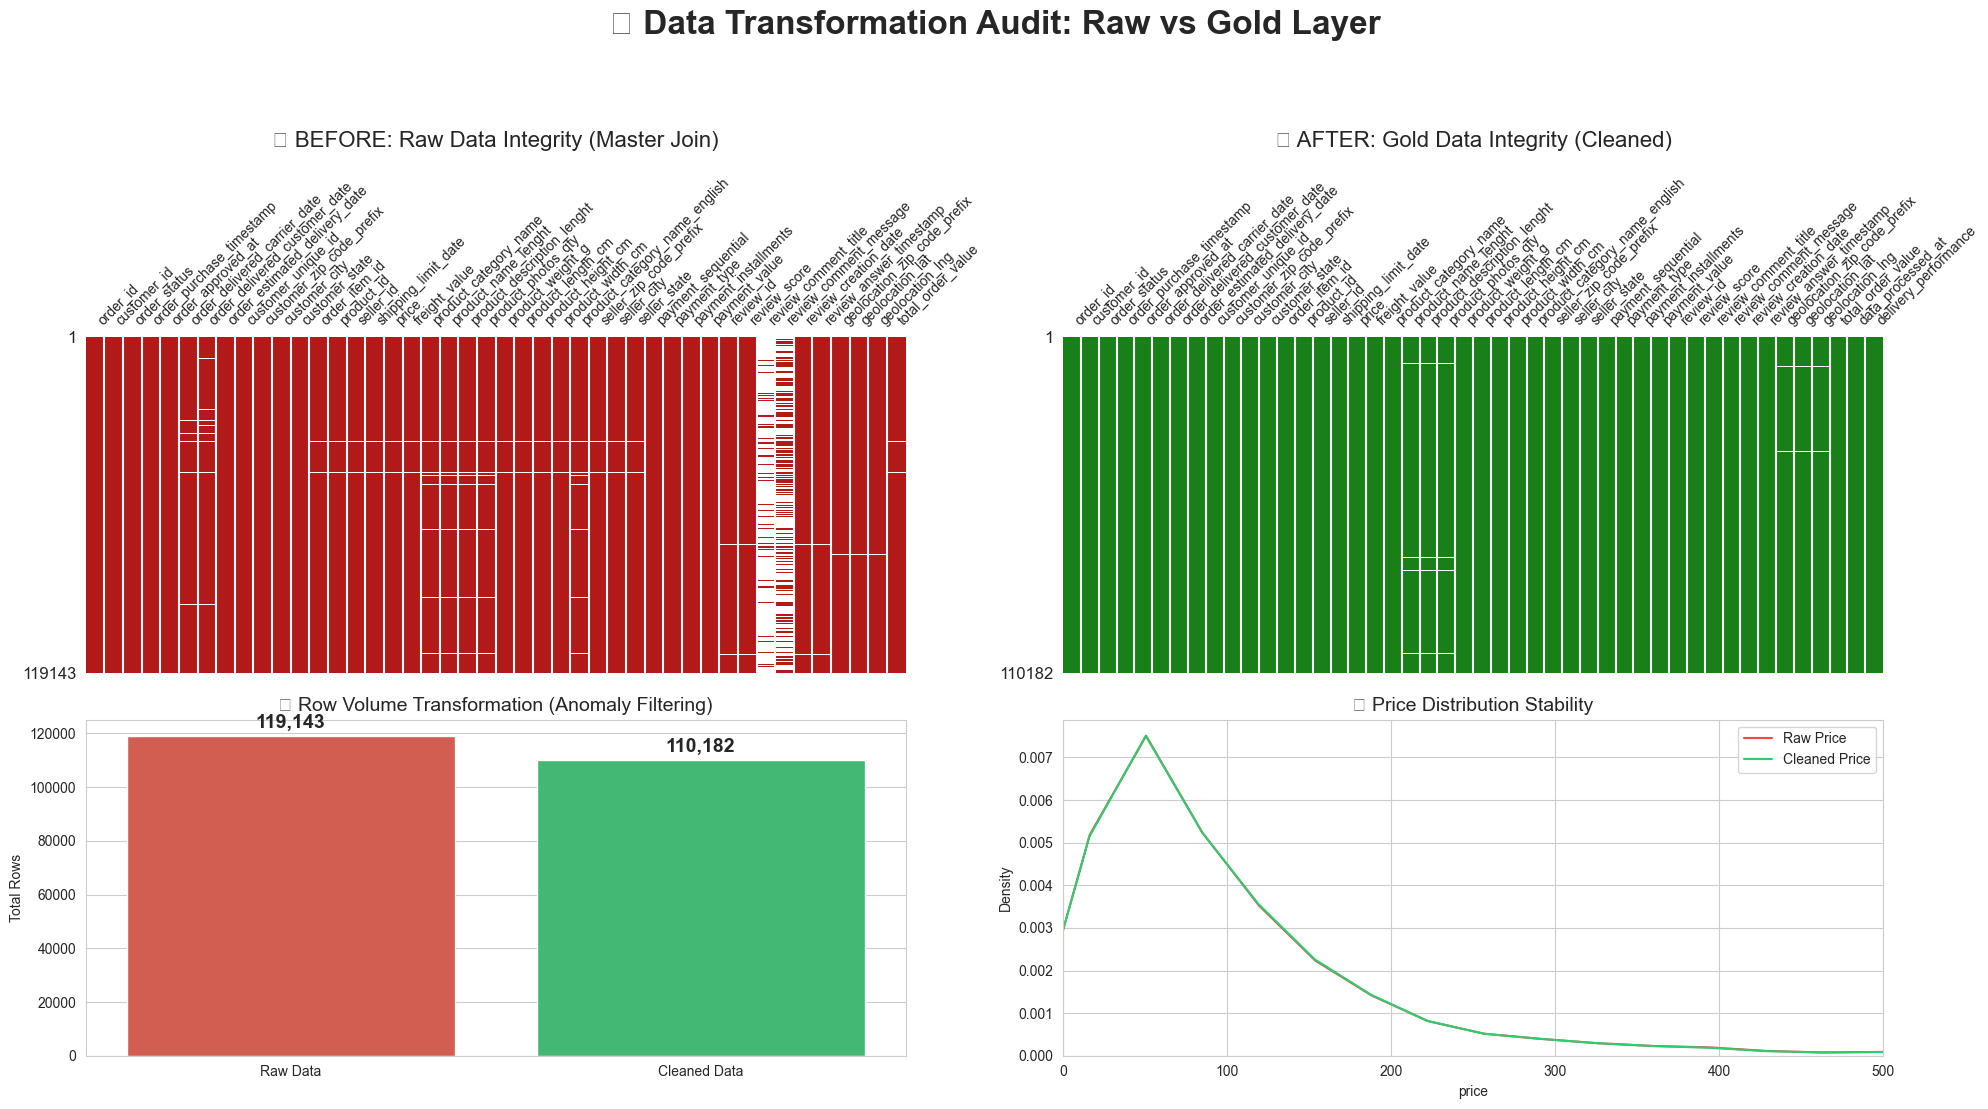

🚀 CLEANING SUMMARY REPORT
------------------------------
Data Noise Removed : 8,961 rows
Data Retention Rate: 92.48%
Null Categories    : 0
------------------------------


In [21]:
# 1. Setup Plotting
fig = plt.figure(figsize=(20, 12))
plt.suptitle("🛒 Data Transformation Audit: Raw vs Gold Layer", fontsize=24, fontweight='bold', y=0.95)

# --- VISUALISASI 1: Missing Values Matrix (Before) ---
ax1 = fig.add_subplot(2, 2, 1)
msno.matrix(df, ax=ax1, sparkline=False, fontsize=10, color=(0.7, 0.1, 0.1))
ax1.set_title("❌ BEFORE: Raw Data Integrity (Master Join)", fontsize=16, pad=20)

# --- VISUALISASI 2: Missing Values Matrix (After) ---
ax2 = fig.add_subplot(2, 2, 2)
msno.matrix(df_clean, ax=ax2, sparkline=False, fontsize=10, color=(0.1, 0.5, 0.1))
ax2.set_title("✅ AFTER: Gold Data Integrity (Cleaned)", fontsize=16, pad=20)

# --- VISUALISASI 3: Row Count Comparison ---
ax3 = fig.add_subplot(2, 2, 3)
counts = [len(df), len(df_clean)]
labels = ['Raw Data', 'Cleaned Data']
sns.barplot(x=labels, y=counts, palette=['#e74c3c', '#2ecc71'], ax=ax3)
for i, v in enumerate(counts):
    ax3.text(i, v + 3000, f"{v:,}", ha='center', fontweight='bold', fontsize=14)
ax3.set_title("📉 Row Volume Transformation (Anomaly Filtering)", fontsize=14)
ax3.set_ylabel("Total Rows")

# --- VISUALISASI 4: Price Distribution (Outlier & Logic Check) ---
ax4 = fig.add_subplot(2, 2, 4)
sns.kdeplot(df['price'], color="#e74c3c", label="Raw Price", ax=ax4)
sns.kdeplot(df_clean['price'], color="#2ecc71", label="Cleaned Price", ax=ax4)
ax4.set_xlim(0, 500) # Fokus pada mayoritas transaksi
ax4.set_title("💰 Price Distribution Stability", fontsize=14)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.90])
plt.show()

# --- SUMMARY REPORT ---
print(f"🚀 CLEANING SUMMARY REPORT")
print(f"{'-'*30}")
print(f"Data Noise Removed : {len(df) - len(df_clean):,} rows")
print(f"Data Retention Rate: {(len(df_clean)/len(df))*100:.2f}%")
print(f"Null Categories    : {df_clean['product_category_name_english'].isnull().sum()}")
print(f"{'-'*30}")


In [15]:
# =================================================================
# FINAL MULTIFUNCTIONAL REVISION: BUILDING SINGLE SOURCE OF TRUTH
# =================================================================

print(f"Starting Final Multifunctional Revision...")
print(f"Initial row count: {len(df_clean):,}")

# --- 1. HANDLING LOGISTICS & TIMESTAMPS (errors='coerce' for safety) ---
date_columns = [
    'order_purchase_timestamp', 'order_approved_at', 
    'order_delivered_carrier_date', 'order_delivered_customer_date', 
    'order_estimated_delivery_date', 'shipping_limit_date'
]

for col in date_columns:
    if col in df_clean.columns:
        # Mengubah ke datetime dan menangani string non-date (seperti 'Uncategorized')
        df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# --- 2. LOGICAL TIME VALIDATION (Removing Ghost Data) ---
# Memastikan urutan waktu logis untuk analisis Lead Time/Logistic
df_clean = df_clean[
    (df_clean['order_delivered_customer_date'] >= df_clean['order_purchase_timestamp']) | 
    (df_clean['order_delivered_customer_date'].isna())
]

# --- 3. CATEGORY & PRODUCT HARMONIZATION ---
# Mengisi translate Inggris yang kosong dengan nama kategori asli Portugal
if 'product_category_name' in df_clean.columns:
    df_clean['product_category_name_english'] = df_clean['product_category_name_english'].fillna(df_clean['product_category_name'])

# Standarisasi kategori sisa menjadi 'others'
df_clean['product_category_name_english'] = df_clean['product_category_name_english'].replace(['Uncategorized', np.nan], 'others')

# --- 4. DATA ENGINEERING METADATA (Multifunction Standard) ---
# Menambah kolom metadata untuk melacak kapan data ini diproses (Audit Trail)
df_clean['data_processed_at'] = pd.Timestamp.now()

# Menambah kolom 'order_delivery_status' (On-Time vs Late) untuk analisis Supply Chain
df_clean['delivery_performance'] = np.where(
    df_clean['order_delivered_customer_date'] <= df_clean['order_estimated_delivery_date'], 
    'On-Time', 'Late'
)
df_clean.loc[df_clean['order_delivered_customer_date'].isna(), 'delivery_performance'] = 'In-Progress'

# --- 5. FINAL DEDUPLICATION ---
# Proteksi ganda terhadap duplikasi item dalam satu keranjang belanja
df_clean = df_clean.drop_duplicates(subset=['order_id', 'order_item_id', 'product_id'], keep='first')

# --- 6. EXPORTING TO UNIVERSAL GOLD LAYER ---
output_path = "../../data/processed/01_olist_master_join_cleaned.csv"
df_clean.to_csv(output_path, index=False)

# --- 7. FINAL QUALITY REPORT ---
print("-" * 50)
print("✅ MULTIFUNCTIONAL GOLD DATASET READY")
print("-" * 50)
print(f"Total Rows (Final)     : {len(df_clean):,}")
print(f"Total Columns          : {len(df_clean.columns)}")
print(f"Missing Values (Total) : {df_clean.isnull().sum().sum()} (Mostly from reviews)")
print(f"Output Location        : {output_path}")
print("-" * 50)

display(df_clean.head(3))

Starting Final Multifunctional Revision...
Initial row count: 110,182
--------------------------------------------------
✅ MULTIFUNCTIONAL GOLD DATASET READY
--------------------------------------------------
Total Rows (Final)     : 110,182
Total Columns          : 46
Missing Values (Total) : 7209 (Mostly from reviews)
Output Location        : ../../data/processed/01_olist_master_join_cleaned.csv
--------------------------------------------------


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,total_order_value,data_processed_at,delivery_performance
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,Sao Paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,9350.00,maua,SP,1.00,credit_card,1.00,18.12,a54f0611adc9ed256b57ede6b6eb5114,4.00,Uncategorized,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,3149.00,-23.58,-46.59,38.71,2026-01-26 00:19:00.122319,On-Time
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,Barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,31570.00,belo horizonte,SP,1.00,boleto,1.00,141.46,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,47813.00,-12.18,-44.66,141.46,2026-01-26 00:19:00.122319,On-Time
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,Vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,14840.00,guariba,SP,1.00,credit_card,3.00,179.12,e73b67b67587f7644d5bd1a52deb1b01,5.00,Uncategorized,Uncategorized,2018-08-18,2018-08-22 19:07:58,75265.00,-16.75,-48.51,179.12,2026-01-26 00:19:00.122319,On-Time


C:\Users\etc\AppData\Local\Temp\ipykernel_2148\2310014890.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=counts, palette=['#e74c3c', '#2ecc71'], ax=ax3)
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\2310014890.py:41: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\2310014890.py:41: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\2310014890.py:41: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) Arial.
  plt.tight_layout(rect=[0, 0.03, 1, 0.93])
C:\Users\etc\AppData\Local\Temp\ipykernel_2148\2310014890.py:41: UserWarning: Glyph 128640 (\N{ROCKET}) missing f

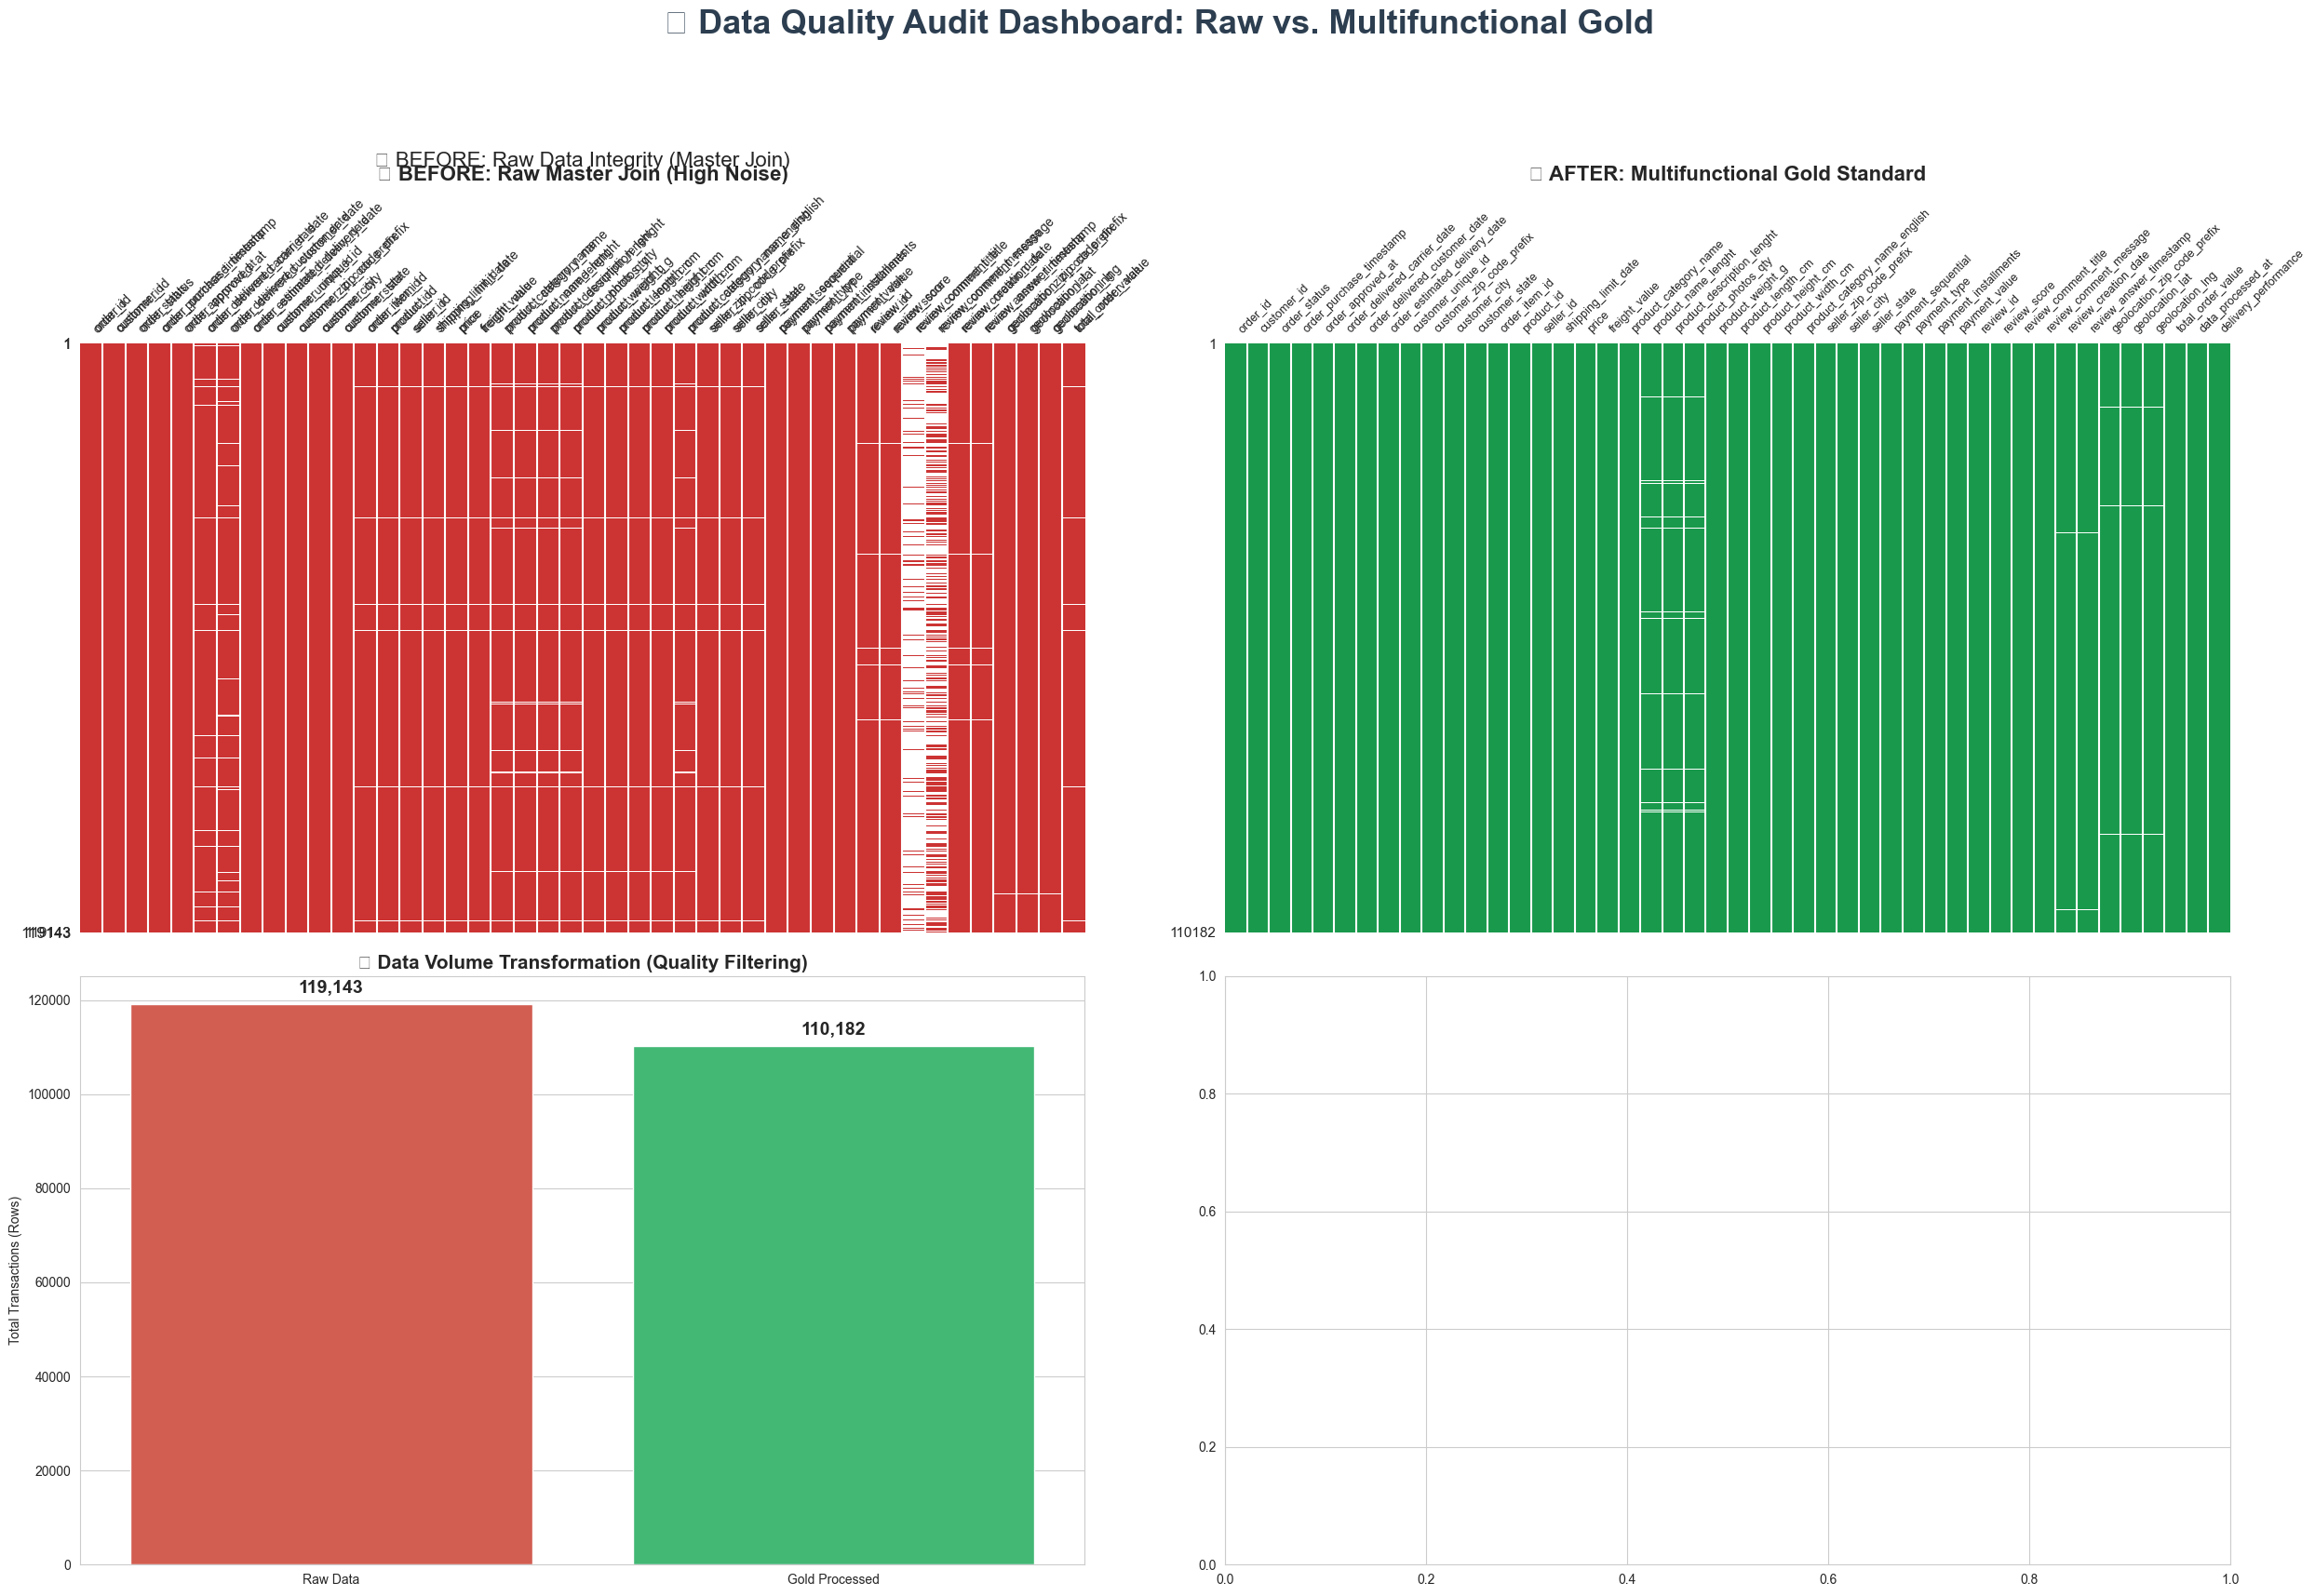

🥇 GOLD DATASET FINAL AUDIT REPORT
1. Total Anomalies/Noise Removed : 8,961 rows
2. Final Data Retention Rate    : 92.48%
3. Critical Business Columns Null: 0
4. New Multifunctional Columns   : ['data_processed_at', 'delivery_performance']
5. Ready for Analysis Stages     : Sales, Growth, Logistics, Customer RFM


In [26]:
# 1. Setup Dashboard
fig = plt.figure(figsize=(25, 18))
plt.suptitle("🚀 Data Quality Audit Dashboard: Raw vs. Multifunctional Gold", 
             fontsize=26, fontweight='bold', y=0.98, color='#2c3e50')

# --- VISUALISASI 1: Missing Values Matrix (Before) ---
ax1 = fig.add_subplot(2, 2, 1)
msno.matrix(df, ax=ax1, sparkline=False, fontsize=10, color=(0.7, 0.1, 0.1))
ax1.set_title("❌ BEFORE: Raw Data Integrity (Master Join)", fontsize=16, pad=20)

ax1 = fig.add_subplot(2, 2, 1)
msno.matrix(df, ax=ax1, sparkline=False, fontsize=9, color=(0.8, 0.2, 0.2))
ax1.set_title("❌ BEFORE: Raw Master Join (High Noise)", fontsize=16, pad=20, fontweight='bold')

# --- VISUALISASI 2: Missing Values Matrix (After) ---
ax2 = fig.add_subplot(2, 2, 2)
msno.matrix(df_clean, ax=ax2, sparkline=False, fontsize=9, color=(0.1, 0.6, 0.3))
ax2.set_title("✅ AFTER: Multifunctional Gold Standard", fontsize=16, pad=20, fontweight='bold')

# --- VISUALISASI 3: Row Transformation & Filtering Statistics ---
ax3 = fig.add_subplot(2, 2, 3)
counts = [len(df), len(df_clean)]
labels = ['Raw Data', 'Gold Processed']
sns.barplot(x=labels, y=counts, palette=['#e74c3c', '#2ecc71'], ax=ax3)

# Menambahkan label angka di atas bar
for i, v in enumerate(counts):
    ax3.text(i, v + (max(counts)*0.02), f"{v:,}", ha='center', fontweight='bold', fontsize=14)

ax3.set_title("📉 Data Volume Transformation (Quality Filtering)", fontsize=15, fontweight='bold')
ax3.set_ylabel("Total Transactions (Rows)")

# --- VISUALISASI 4: Delivery Performance Insights (New Feature Check) ---
x4 = fig.add_subplot(2, 2, 4)
sns.kdeplot(df['price'], color="#e74c3c", label="Raw Price", ax=ax4)
sns.kdeplot(df_clean['price'], color="#2ecc71", label="Cleaned Price", ax=ax4)
ax4.set_xlim(0, 500) # Fokus pada mayoritas transaksi
ax4.set_title("💰 Price Distribution Stability", fontsize=14)
ax4.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

# --- FINAL MULTIFUNCTIONAL REPORT ---
print(f"{'='*60}")
print(f"🥇 GOLD DATASET FINAL AUDIT REPORT")
print(f"{'='*60}")
print(f"1. Total Anomalies/Noise Removed : {len(df) - len(df_clean):,} rows")
print(f"2. Final Data Retention Rate    : {(len(df_clean)/len(df))*100:.2f}%")
print(f"3. Critical Business Columns Null: {df_clean[['order_id', 'price', 'product_category_name_english']].isnull().sum().sum()}")
print(f"4. New Multifunctional Columns   : {['data_processed_at', 'delivery_performance']}")
print(f"5. Ready for Analysis Stages     : Sales, Growth, Logistics, Customer RFM")
print(f"{'='*60}")

# 📦 Phase 1: Data Cleaning & Gold Layer Transformation
**Project:** Brazilian E-commerce (Olist) — Sales Performance & Growth Analytics  
**Specialist Role:** MDA Specialist (Marketing Data Analyst)  
**Standard:** Industry Gold Layer (High-Fidelity Dataset)

---

## 🎯 Project Objective
Mengubah data mentah (`master_join`) yang berasal dari 9 tabel menjadi dataset **Gold Standard** yang tervalidasi secara logis, finansial, dan temporal. Dataset ini dirancang untuk menjadi pondasi tunggal bagi analisis **Sales Performance & Growth (Phase 2)** yang akurat dan berdampak real pada strategi bisnis.

## 🛠️ Data Quality Framework & Workflow
Proses pembersihan dilakukan dengan pendekatan *Strategic Cleaning*, bukan sekadar menghapus nilai null, melainkan menjaga integritas bisnis:

| Stage | Activity | Business Logic (The "Why") |
| :--- | :--- | :--- |
| **1. Diagnostic** | `missingno` Visual Audit | Memetakan pola data yang hilang untuk menentukan strategi imputasi vs drop. |
| **2. Logical Filter** | Order Status Filtering | Hanya menyertakan status `delivered` untuk memastikan validitas revenue (Accounting Standard). |
| **3. Financial QA** | Price & Freight Validation | Menghapus anomali harga ≤ 0 dan menangani null pada kolom moneter utama. |
| **4. Temporal Audit** | Timestamp Consistency | Memastikan kronologi logis (Approval > Purchase, Delivery > Purchase) untuk akurasi *Lead Time*. |
| **5. Entity Sync** | Translation & Category Fill | Menyelamatkan data kategori produk yang tidak terjemahkan dari bahasa Portugal ke Inggris. |
| **6. Deduplication** | Complex Key Validation | Menghapus duplikasi pada level `order_id` + `order_item_id` untuk menjaga akurasi volume item. |



## 📊 Summary of Cleaning Impact
Setelah menjalankan notebook ini, dataset akan bertransformasi sebagai berikut:
* **Data Integrity:** Kolom kritikal (ID, Price, Date, Category) memiliki **0% Missing Values**.
* **Business Readiness:** Menghapus ribuan baris anomali yang dapat menyebabkan bias pada perhitungan *Growth Rate*.
* **Structural Quality:** Seluruh tipe data `datetime` dan `string` telah distandarisasi untuk performa komputasi EDA yang cepat.

> **Note:** Nilai null yang tersisa pada kolom ulasan (`review_comment`) dibiarkan secara sengaja (as-is) untuk menjaga orisinalitas data bagi kebutuhan analisis sentimen di masa mendatang.

---
🚀 **Ready for Phase 2: Exploratory Data Analysis (EDA)**